# Linear Regression 3.4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


## Original Linear Regression Model Attempt

In [2]:
# Load the dataset
df_popularity0 = pd.read_csv('tracks2026.csv')
# These two decisions are explained in EDA and Data_Preparation
df_popularity0 = df_popularity0.dropna() 
df_popularity0 = df_popularity0.drop(columns = ["track_id"])

In [3]:
target = 'popularity'
X0 = df_popularity0.drop(columns=[target])
y0 = df_popularity0[target]

In [4]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X0.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df_popularity0.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df_popularity0[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df_popularity0[col].min() >= 0]
# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track-genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, ["track_genre"] )
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [5]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

# Setting a CV score
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Scoring variable
scoring = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

# Split the data (80% training, 20% testing)
X_train0, X_test0, y_train0, y_test0 = train_test_split(X0, y0, test_size=0.2, random_state=42)

# Linear Regression Pipeline
pipe0 = Pipeline(steps = [('preprocess', preprocess_pipeline),
                         ('reduce_dim', PCA(iterated_power=7)),
                        ('regressor', LinearRegression())
                         ]
                         )


In [6]:
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE

# Setting a smaller amount of alternative values

N_FEATURES_OPTIONS = [2, 6, 11, 15, 19]
FIT_INTERCEPT_OPTIONS = [False, True]

param_grid = [
    {
        'reduce_dim': [PCA(iterated_power=7)],
        'reduce_dim__n_components': N_FEATURES_OPTIONS,
        'regressor__fit_intercept': FIT_INTERCEPT_OPTIONS
    },
    {
        'reduce_dim': [RFE(svm.SVR(kernel='linear', gamma='auto')),RFE(LinearRegression())],
        'reduce_dim__n_features_to_select': N_FEATURES_OPTIONS,
        'regressor__fit_intercept': FIT_INTERCEPT_OPTIONS
    }  
]


In [7]:
from sklearn import set_config

# Display pipeline in a more visual format
set_config(display='diagram')
pipe0

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('reduce_dim', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('no_outliers', ...), ('outliers_neg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [8]:
from sklearn.model_selection import GridSearchCV


lr_search0 = GridSearchCV(
    pipe0, 
    param_grid,
    scoring=scoring,    
    n_jobs=-1,
    cv=cv10,
    refit="R2",
    return_train_score=False)
# Initialize and train the Linear Regression model
lr_search0.fit(X_train0, y_train0)

print(f"Best parameters: {lr_search0.best_params_}")
print(f"Best R2 score: {lr_search0.best_score_:.4f}")

Best parameters: {'reduce_dim': RFE(estimator=LinearRegression()), 'reduce_dim__n_features_to_select': 11, 'regressor__fit_intercept': True}
Best R2 score: 0.0139


The R2 score is very low on this linear regression model, and looking at the graph we can see that there are a lot of zeros in the data set, a possibility could be that removing the zeros could improve the R2 score of the new linear regression model

## Looking at why the R2 could be so low

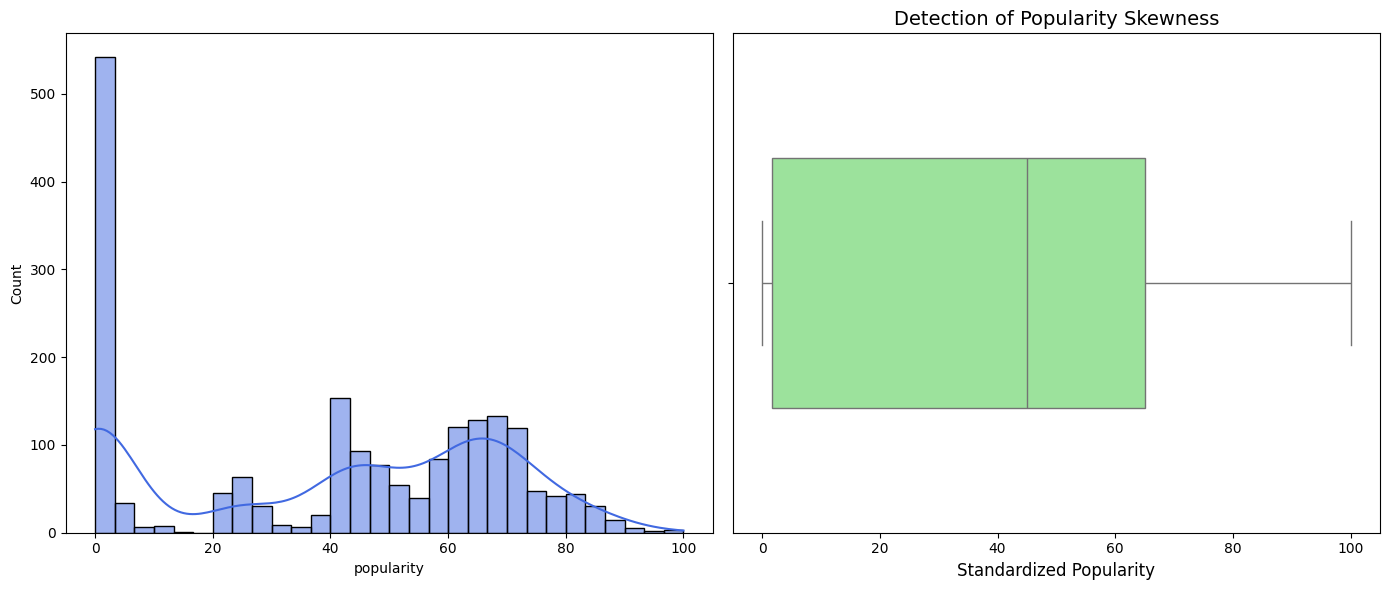

--- DATASET CLEANING SUMMARY ---
Original Song Count: 2000
Filtered Song Count: 1538
Total Songs Removed: 462 (0 Popularity Songs)
New Mean Popularity: 50.7269 
---------------------------------


In [9]:
import seaborn as sns
# 1. Load the original transformed dataset
dfexample = pd.read_csv('tracks2026.csv')

# 2. Visualize the Problem: The "Long Tail" of Low Popularity
plt.figure(figsize=(14, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(dfexample['popularity'], kde=True, color='royalblue', bins=30)

# Boxplot to show spread and density
plt.subplot(1, 2, 2)
sns.boxplot(x=dfexample['popularity'], color='lightgreen', width=0.5)
plt.title('Detection of Popularity Skewness', fontsize=14)
plt.xlabel('Standardized Popularity', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Create a filtered DataFrame (Removing the bottom 25%)
df_filtered = dfexample[dfexample['popularity'] > 0]

# 4. Impact Summary for the team
print("--- DATASET CLEANING SUMMARY ---")
print(f"Original Song Count: {len(dfexample)}")
print(f"Filtered Song Count: {len(df_filtered)}")
print(f"Total Songs Removed: {len(dfexample) - len(df_filtered)} (0 Popularity Songs)")
print(f"New Mean Popularity: {df_filtered['popularity'].mean():.4f} ")
print("---------------------------------")

## Linear regression model with zeros taken out

In [10]:
# Load the transformed dataset
# Perform the same cleaning steps with the new justified set as well
df = pd.read_csv('tracks2026.csv')
df = df.drop(columns = ["track_id"])
df = df.dropna()

# Define features (X) and target (y)
target = 'popularity'
X = df.drop(columns=[target])
y = df[target]

In [11]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]
# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track-genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, ["track_genre"] )
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [12]:
# Setting a CV score
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Scoring variable
scoring = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Taking out zeros from the training set, but not the test set, to avoid data leakage
X_train_filtered = X_train[y_train > 0]
y_train_filtered = y_train[y_train > 0]

# Linear Regression Pipeline
pipe0 = Pipeline(steps = [('preprocess', preprocess_pipeline),
                         ('reduce_dim', PCA(iterated_power=7)),
                        ('regressor', LinearRegression())
                         ]
                         )


In [13]:


lr_search = GridSearchCV(
    pipe0, 
    param_grid,
    scoring=scoring,    
    n_jobs=-1,
    cv=cv10,
    refit="R2",
    return_train_score=False)
# Initialize and train the Linear Regression model
lr_search.fit(X_train_filtered, y_train_filtered)

print(f"Best parameters: {lr_search.best_params_}")

# Evaluating on unfileterd test data
y_pred = lr_search.predict(X_test)
r2_realistic = r2_score(y_test, y_pred)
print("R2 Score on Unfiltered Test Set (Realistic Evaluation): ", r2_realistic)

Best parameters: {'reduce_dim': RFE(estimator=SVR(gamma='auto', kernel='linear')), 'reduce_dim__n_features_to_select': 19, 'regressor__fit_intercept': True}
R2 Score on Unfiltered Test Set (Realistic Evaluation):  -0.19890460672088528


Looks like this approach reduced the R2 score when applied to the test set

## Comparison of two models

Here I am comparing the two models side by side, to showcase the difference in MSE, MAE, and R2 score

In [14]:
print("R2 Score with no removal of 0 Popularity Songs: ", lr_search0.best_score_)
print("R2 Score with Justified Removal of 0 Popularity Songs (Unrealistic): ", lr_search.best_score_)
print("R2 Score on Unfiltered Test Set (Realistic): ", r2_realistic)

R2 Score with no removal of 0 Popularity Songs:  0.013889304398040436
R2 Score with Justified Removal of 0 Popularity Songs (Unrealistic):  0.09079475070822826
R2 Score on Unfiltered Test Set (Realistic):  -0.19890460672088528


We can see that once we remove the zeros we are able to get a slightly better R2 score on the practice data without zeros, but we end up doing much worse on the test set that includes zeros.

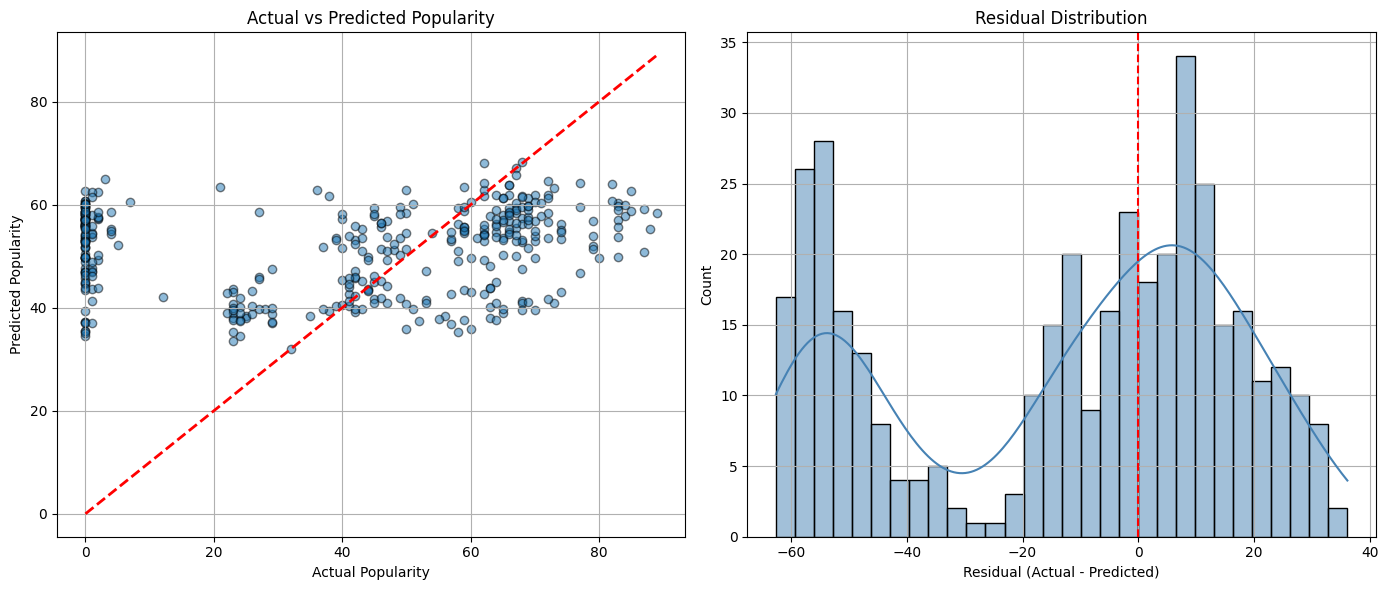

In [15]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity')
plt.grid(True)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='steelblue', bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.grid(True)

plt.tight_layout()
plt.show()

## Conclusion
Working on this linear regression model was a two step process, the first attempt and then a later attempt after getting usatisfactory results witht he first attempt.
We were able to recognize an issue with the model with the amount of zeros that were in the popularity metric. This made it very difficult to get an accurate linear regression model because of how biased the model is, so we came to the decision to remove the zeros from the model.

When we removed the zeros from the model we were able to get a better reading on the training data, but got a worse R2 score on the test data that still included the zeros, so removing the zeros from the training data reduced the accuracy of the model instead of increasing it on real world data.

Overall this data set is very hard to fit to a highly biased regression model such as linear regression, this could be because the popularity of a song is much more dependent than just the characteristics of a song.

For example popularity also has to do with current trends, artist who posted the song, traction/hype, etc. All things not represented in this data set and would be hard to represent as well.